In [ ]:
import pandas as pd
import numpy as np
import datetime as dt

# 1. Veriyi Yükleme
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

print("Veri setinin ilk 5 satırı:")
display(df.head())

# 2. Veri Temizleme
# İptal edilen siparişleri ve Müşteri ID'si olmayanları çıkarma
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
df.dropna(subset=['CustomerID'], inplace=True)

# Hatalı verileri eleme
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Toplam harcama kolonunu oluşturma (Fiyat * Miktar)
df['Total_Price'] = df['Quantity'] * df['UnitPrice']

# Tarih kolonunu datetime kolonuna çevirme (Geçen zamanı yazdırabilmek için)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. RFM Özellik Belirleme
# Analiz tarihi olarak veri setindeki en son tarihten 1 gün sonrasını alıyorum (test için ki zaten güncel bir veri setiyse uygulamayı 1 gün önce kullanan illaki vardır)
analysis_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Müşteri bazında gruplayarak RFM metriklerini hesaplama
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days, # Recency (Yenilik): Son alışverişten bu yana geçen gün
    'InvoiceNo': 'nunique',                                   # Frequency (Sıklık): Toplam eşsiz sipariş sayısı
    'Total_Price': 'sum'                                      # Monetary (Parasal Değer): Toplam bırakılan para
})

# Kolon isimlerini düzenliyoruz
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Hedef Değişkeni (Churn) Belirleme
# İş Kuralı: Son 180 günde hiç alışveriş yapmayan müşteriyi "Churn" (Terk Etmiş - 1) kabul edelim.
rfm['Churn'] = np.where(rfm['Recency'] > 180, 1, 0)

print("\nRFM ve Churn Tablosu:")
display(rfm.head())

print("\nChurn Dağılımı:")
print(rfm['Churn'].value_counts())

Veri setinin ilk 5 satırı:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



RFM ve Churn Tablosu:


,Recency,Frequency,Monetary,Churn
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1



Churn Dağılımı:
Churn
0    3478
1     860
Name: count, dtype: int64


Model V1

Sınıflandırma Raporu (Classification Report):

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       696
           1       0.40      0.38      0.39       172

    accuracy                           0.76       868
   macro avg       0.62      0.62      0.62       868
weighted avg       0.76      0.76      0.76       868



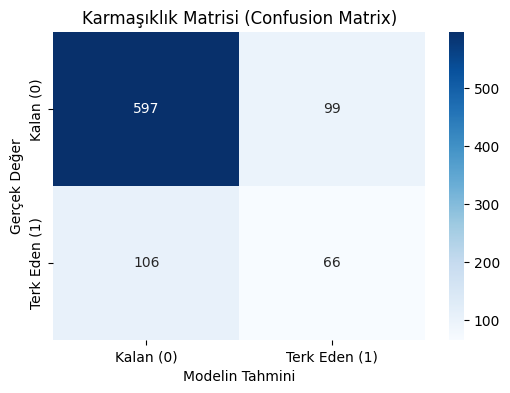

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Özellikler (X) ve Hedef Değişken (y) Belirleme
# Veri sızıntısını önlemek için 'Recency' kolonunu X'ten çıkarıyorum
X = rfm[['Frequency', 'Monetary' ]]
y = rfm['Churn']

# 2. Veriyi Eğitim ve Test Olarak İkiye Ayırma
# Verinin %80'i ile modeli eğiteceğiz, %20'si ile test edeceğiz.
# 'stratify=y' parametresi, her iki sete de dengeli oranda churn olan/olmayan müşteri dağıtılmasını sağlıyor.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Makine Öğrenmesi Modelini Tanımlama ve Eğitme
# Dengesiz veri setimiz olduğu için class_weight='balanced' kullanıyorum.
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Test Verisi Üzerinde Tahmin Yapma
y_pred = model.predict(X_test)

# 5. Sonuçları Değerlendirme ve Görselleştirme
print("Sınıflandırma Raporu (Classification Report):\n")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix) Çizimi

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kalan (0)', 'Terk Eden (1)'],
            yticklabels=['Kalan (0)', 'Terk Eden (1)'])
plt.ylabel('Gerçek Değer')
plt.xlabel('Modelin Tahmini')
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.show()

Model V2

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Yeni Özellik (Feature) Ekleme: Ortalama Sipariş Değeri (AOV)
X_v2 = rfm[['Frequency', 'Monetary']].copy()
X_v2['AOV'] = X_v2['Monetary'] / X_v2['Frequency']

y_v2 = rfm['Churn']

# Veriyi tekrar Train/Test olarak ayırıyorum(Smote uygularken test verisine ellememek için)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2)

# 2. SMOTE Uygulaması (Çok Kritik: SMOTE SADECE Eğitim verisine uygulanır, Test verisi orijinal kalmalı)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_v2, y_train_v2)

# 3. Modeli Tekrar Eğitme
model_v2 = RandomForestClassifier(random_state=42)
model_v2.fit(X_train_smote, y_train_smote)

# 4. Tahmin ve Yeni Rapor
y_pred_v2 = model_v2.predict(X_test_v2)

print("Versiyon 2 Sınıflandırma Raporu (SMOTE + AOV):\n")
print(classification_report(y_test_v2, y_pred_v2))

Versiyon 2 Sınıflandırma Raporu (SMOTE + AOV):

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       696
           1       0.34      0.56      0.42       172

    accuracy                           0.70       868
   macro avg       0.60      0.64      0.61       868
weighted avg       0.76      0.70      0.72       868

